# W13 · MotrixSim 物理引擎入门

> 阶段二（M5–M6）：MotrixLab —— 国产 Sim2Real 能力 · 第 1/6 讲

从这一讲开始，我们从「算法」走向「物理」。阶段一里，`gym.make("CartPole-v1")` 一行代码就能给你一个世界；
而在真实机器人项目中，这个世界需要你自己用**物理仿真引擎**搭出来。本讲带你认识国产物理仿真引擎
**MotrixSim**（谋先飞 Motphys 出品），理解它的心智模型，并搞清楚一个关键问题：**并行仿真为什么快**。

## 学习目标

完成本讲后，你应该能够：

1. 用一句话说清物理仿真引擎在 RL 闭环中扮演的角色（MDP 中 $p(s'|s,a)$ 的实现者）；
2. 解释 `SceneModel`（静态描述）与 `SceneData`（动态状态）分离设计的意义；
3. 读懂一个最小 MJCF 模型文件，并跑通官方「Hello MotrixSim」示例（需本机安装 MotrixSim）；
4. 解释「同一模型 + 批量数据实例」为什么能带来几个数量级的采样吞吐；
5. 用 numpy 向量化亲手验证「批量化」带来的加速比。

> **本讲可执行性说明**：概念演示（积分器、向量化基准）使用纯 numpy，可直接在本机运行；
> 涉及 MotrixSim 的代码 cell 均标注了「运行前提」，本机未安装 MotrixSim 时保持未执行状态，
> 并附预期输出描述。安装方法见 `docs/phase2_motrixlab.md`。

## 1.1 物理引擎是什么：RL 闭环里的「世界」

回忆阶段一的 MDP 五元组 $(\mathcal{S}, \mathcal{A}, p, r, \gamma)$。在 CartPole 里你从未关心过
$p(s'|s,a)$ 是谁算的——它藏在 `env.step()` 里。对机器人任务，这个转移函数由**刚体动力学**给出：

$$
M(q)\,\ddot{q} + C(q,\dot{q}) = \tau_{\text{actuator}} + \tau_{\text{contact}} + \tau_{\text{ext}}
$$

其中 $q$ 是广义坐标（关节角度等），$M(q)$ 是质量矩阵，$C$ 包含科氏力/重力项，$\tau$ 是各类力矩。
物理仿真引擎的职责就是：给定当前状态 $(q, \dot q)$ 和动作 $\tau_{\text{actuator}}$，
数值求解上式并积分出下一时刻状态。

**直觉类比**：物理引擎之于机器人 RL，就像游戏引擎之于游戏 AI——它负责「世界如何演化」，
你的策略只负责「看到世界后怎么动」。阶段一你用的 Gymnasium 环境内部其实也是简化版物理引擎，
只是 CartPole 的动力学只有 4 个状态、没有接触；而一只四足机器人每一步都要解算
**十几个关节 + 四点接触力**，这就是需要专业引擎的原因。

**为什么国产引擎值得关注**：长期以来这个领域被 MuJoCo、Isaac Gym（PhysX）、Bullet 等海外引擎主导。
MotrixSim 是国产自研引擎（CPU 版本基于 Rust 开发），对 MJCF 模型格式高度兼容，
并且在 CPU 上就能做大规模并行仿真——对没有高端 GPU 的学习者非常友好。

## 1.2 `step()` 里发生了什么：数值积分与稳定性

引擎拿到加速度 $\ddot q$ 后，需要**数值积分**得到下一时刻的速度和位置。最常用的方案是
**半隐式欧拉（semi-implicit Euler / symplectic Euler）**：

$$
\dot q_{t+1} = \dot q_t + \ddot q_t \,\Delta t, \qquad
q_{t+1} = q_t + \dot q_{t+1}\,\Delta t
$$

注意第二步用的是**更新后的**速度。这个看似微小的差别，决定了仿真是否稳定：
显式欧拉（用旧速度更新位置）会把能量越积越多，系统像「吹气球」一样发散；
半隐式欧拉则保持能量有界。下面亲手验证一下——理解了它，你就理解了为什么
物理引擎的时间步长（timestep）不能随便调大，也理解了 MJCF 里 `<option timestep="0.001"/>`
这行配置的分量。

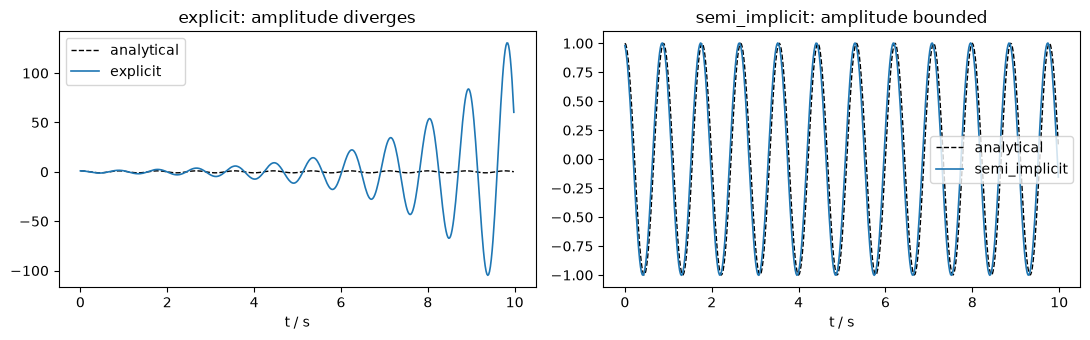

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# 一个最简单的振动系统：单位质量弹簧振子  x'' = -k*x （解析解为等幅简谐振动）
k = 50.0          # 弹簧刚度
dt = 0.02         # 仿真步长 —— 故意取得偏大，让稳定性差异显形
T = 10.0          # 仿真 10 秒
n_steps = int(T / dt)
t = np.arange(n_steps) * dt

def simulate(integrator: str) -> np.ndarray:
    '''返回位置轨迹。integrator ∈ {"explicit", "semi_implicit"}'''
    x, v = 1.0, 0.0
    xs = np.empty(n_steps)
    for i in range(n_steps):
        a = -k * x
        if integrator == "explicit":
            x_new = x + v * dt        # 用旧速度更新位置（显式欧拉）
            v_new = v + a * dt
        else:
            v_new = v + a * dt        # 先更新速度
            x_new = x + v_new * dt    # 用新速度更新位置（半隐式欧拉）
        x, v = x_new, v_new
        xs[i] = x
    return xs

x_exact = np.cos(np.sqrt(k) * t)   # 解析解

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for ax, name in zip(axes, ["explicit", "semi_implicit"]):
    xs = simulate(name)
    ax.plot(t, x_exact, "k--", lw=1, label="analytical")
    ax.plot(t, xs, lw=1.2, label=name)
    label_cn = "diverges" if abs(xs[-1]) > 1.5 else "bounded"
    ax.set_title(f"{name}: amplitude {label_cn}")
    ax.set_xlabel("t / s"); ax.legend()
plt.tight_layout(); plt.show()

可以看到：同样的步长下，显式欧拉的振幅不断放大（能量被数值积分「凭空注入」），
而半隐式欧拉虽然相位有误差，振幅却始终有界。真实引擎（MotrixSim、MuJoCo 等）内部
还要解**接触约束**（脚不能穿地）、**关节限位**等，求解器的稳定性设计远比这个玩具复杂，
但核心思想一致：**宁可损失一点精度，也要保证长时间仿真不发散**。

## 1.3 MotrixSim 心智模型：`SceneModel` 与 `SceneData`

MotrixSim 的 API 围绕两个核心对象展开（[官方文档 · 模型](https://motrixsim.readthedocs.io/zh-cn/latest/user_guide/main_function/scene_model.html)）：

| 对象 | 存什么 | 类比 |
|------|--------|------|
| `SceneModel` | **不随时间变化**的量：几何形状、质量属性、关节连接、执行器配置 | 建筑**图纸** |
| `SceneData` | **随时间变化**的量：关节位置/速度、物体位姿、传感器读数 | 图纸盖出来的**工地** |

为什么要分开？因为 RL 需要同时跑成千上万个环境副本。如果「图纸」和「工地」混在一起，
每个副本都要复制一份完整模型，浪费内存且无法批量计算。分离之后：
**一个 `SceneModel` + N 个 `SceneData` 实例**，就能用一份模型描述驱动 N 个互不影响的仿真世界。
这正是 1.5 节并行仿真的基础，也是 Isaac Gym 等引擎的同款设计（Isaac 里叫 asset / env 分离）。

机器人模型用 **MJCF**（MuJoCo XML 格式）描述，MotrixSim 对 MJCF 高度兼容，也支持 URDF 与 USD。
下面是一个最小 MJCF：两个自由落体小球（来自官方文档示例）。注意 `<freejoint/>` 表示
该刚体相对世界有 6 个自由度（3 平移 + 3 旋转），`timestep` 就是上一节的 $\Delta t$：

```xml
<mujoco>
    <option timestep="0.001"/>
    <worldbody>
        <light name="light" pos="0 0 3"/>
        <geom name="floor" size="0 0 0.05" type="plane"/>
        <body pos="0 0 0.1">
            <freejoint/>
            <geom type="sphere" size=".1" />
        </body>
        <body pos="0.01 0 0.3">
            <freejoint/>
            <geom type="sphere" size=".1" />
        </body>
    </worldbody>
</mujoco>
```

### 运行示例：Hello MotrixSim

下面的代码是[官方「Hello MotrixSim」](https://motrixsim.readthedocs.io/zh-cn/latest/user_guide/getting_started/hello_motrixsim.html)
示例：加载 Spot 机器狗模型并做物理仿真。核心 API 只有四个：
`mx.load_model(path)`（加载 MJCF/URDF/USD）、`mx.SceneData(model)`（创建动态数据）、
`model.step(data)`（推进一步物理）、`mx.render.RenderApp`（可视化）。

> **运行前提**：本机已 `uv add motrixsim`（见 `docs/phase2_motrixlab.md`），
> 且 `assets/boston_dynamics_spot/scene.xml` 模型文件已按官方教程下载。
> 本机未安装 MotrixSim，此 cell 保持未执行。
>
> **预期输出**：弹出一个渲染窗口，Spot 四足机器人在重力作用下自然站立、保持平衡，
> 仿真持续运行直到手动关闭窗口。

In [ ]:
# ⚠️ 运行前提：本机已安装 motrixsim 且已下载示例模型；本 cell 在教学机上保持未执行
import motrixsim as mx

# 加载模型文件（包含物理和渲染数据）
model = mx.load_model("assets/boston_dynamics_spot/scene.xml")

# 创建渲染器（"warn" 表示日志级别）
with mx.render.RenderApp("warn") as render:
    render.launch(model)          # 渲染器加载模型
    data = mx.SceneData(model)    # 创建物理数据对象
    while True:                   # 无限循环运行仿真
        model.step(data)          # 执行一步物理仿真
        render.sync(data)         # 同步数据到渲染器

模型加载后，可以通过 **Named Access**（按名称或索引）访问任意组件，
并通过 `SceneData` 读写状态（[官方文档 · 数据](https://motrixsim.readthedocs.io/zh-cn/latest/user_guide/main_function/scene_data.html)）：

> **运行前提**：同上，本 cell 保持未执行。
>
> **预期输出**：打印模型中全部关节的名称列表，以及某个铰链关节当前的位置与速度
> （仿真刚启动时接近 0）。

In [ ]:
# ⚠️ 运行前提：同上一 cell，本 cell 保持未执行
import motrixsim as mx

model = mx.load_model("assets/boston_dynamics_spot/scene.xml")
data = mx.SceneData(model)

# 批量访问：关节数量与名称
print("num_joints:", model.num_joints)
print("joint_names:", model.joint_names)

# 按名称访问单个组件，并通过组件读写 SceneData 中的状态
hinge = model.get_joint("fl_hx")   # Spot 左前腿髋关节（名称以实际模型为准）
dof_pos = hinge.get_dof_pos(data)  # 关节位置
dof_vel = hinge.get_dof_vel(data)  # 关节速度
print(f"fl_hx: pos={dof_pos}, vel={dof_vel}")

# 也可以直接拿整个状态数组（numpy 视图）
pos_all = data.dof_pos_array
vel_all = data.dof_vel_array
print("dof_pos_array shape:", pos_all.shape)

## 1.4 并行仿真为什么快

RL 是出了名的「数据吞噬兽」：PPO 训练一个四足行走策略通常需要 **数千万到数亿** 步环境交互。
如果每个环境每步耗时 1 ms，串行收集 1 亿步需要 **约 28 小时**——这还只是一次训练。
并行仿真从三个层面解决吞吐问题：

1. **批量化消除 Python 开销**：逐环境 `for` 循环里，每步都要跨 Python↔引擎边界往返一次，
   解释器开销常常超过物理计算本身。把 N 个环境的状态拼成大数组，一次调用算完所有环境，
   开销被摊薄到接近零。
2. **CPU 多核 / SIMD**：N 个环境之间天然独立（没有数据依赖），是「令人尴尬的并行」，
   多核可以近乎线性加速。MotrixSim 的 CPU 版本基于 Rust 开发，官方宣传一台笔记本可并行
   数千个训练环境；大规模 GPU 并行则可到上万个。
3. **算法结构匹配**：on-policy 算法（PPO）每一步本来就要用当前策略采一大批数据，
   批量环境产出的正好是形状为 `(num_envs, dim)` 的张量，直接喂给 GPU 上的策略网络。

下面用 numpy 亲手验证第 1 点——同样的弹簧振子，分别用「逐环境 Python 循环」和
「批量向量化」两种方式仿真，测量吞吐差异：

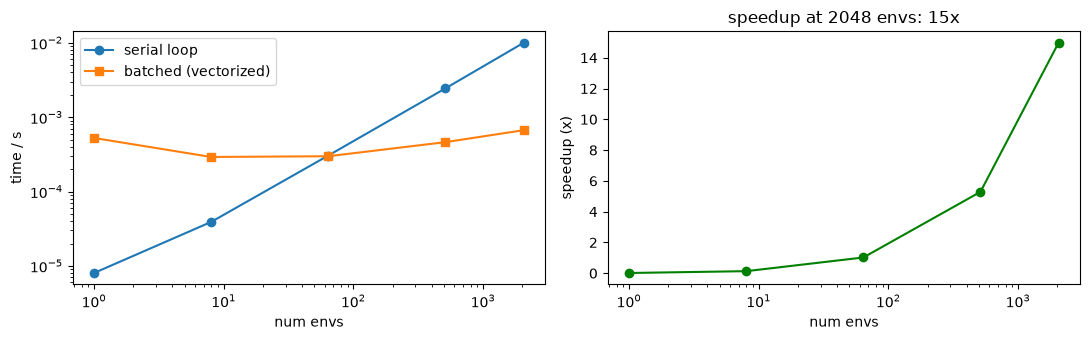

In [2]:
import time

import matplotlib.pyplot as plt
import numpy as np

k, dt, T = 50.0, 0.02, 2.0
n_steps = int(T / dt)

def sim_serial(num_envs: int) -> float:
    '''逐环境 Python 循环：返回总耗时（秒）'''
    t0 = time.perf_counter()
    for _ in range(num_envs):
        x, v = 1.0, 0.0
        for _ in range(n_steps):
            v += -k * x * dt
            x += v * dt
    return time.perf_counter() - t0

def sim_batched(num_envs: int) -> float:
    '''向量化：所有环境的状态拼成数组，一次 numpy 运算算完'''
    t0 = time.perf_counter()
    x = np.ones(num_envs)
    v = np.zeros(num_envs)
    for _ in range(n_steps):
        v += -k * x * dt
        x += v * dt
    return time.perf_counter() - t0

env_counts = [1, 8, 64, 512, 2048]
serial_t = [sim_serial(n) for n in env_counts]
batch_t = [sim_batched(n) for n in env_counts]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(env_counts, serial_t, "o-", label="serial loop")
axes[0].plot(env_counts, batch_t, "s-", label="batched (vectorized)")
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xlabel("num envs"); axes[0].set_ylabel("time / s"); axes[0].legend()
speedup = [s / b for s, b in zip(serial_t, batch_t)]
axes[1].plot(env_counts, speedup, "o-", color="green")
axes[1].set_xscale("log"); axes[1].set_xlabel("num envs"); axes[1].set_ylabel("speedup (x)")
axes[1].set_title(f"speedup at 2048 envs: {speedup[-1]:.0f}x")
plt.tight_layout(); plt.show()

两条曲线的形状说明了问题：逐环境循环的耗时**随环境数线性增长**（每个环境都要付一次
Python 循环的全价）；向量化版本在几百个环境以内耗时几乎不变——多算 500 个环境只是把
numpy 数组拉长一点，而 numpy 底层是连续的 C 循环，单个元素的成本极低。

当然，真实物理引擎远比弹簧振子复杂（接触求解、碰撞检测），不可能全部向量化到这种程度，
但思想完全一致：**把「每环境一次调用」变成「所有环境一次批量调用」**。
MotrixSim 的批量接口就是在 `SceneData` 上加一个 `batch` 维度：

> **运行前提**：本机已安装 MotrixSim 及示例模型；本 cell 保持未执行。
>
> **预期输出**：16 个仿真实例并行推进（若接渲染器，可在窗口中看到 4×4 排布的
> 16 个场景同时下落/运动），各实例互不影响。

In [ ]:
# ⚠️ 运行前提：本机已安装 motrixsim 及示例模型；本 cell 保持未执行
import motrixsim as mx
import numpy as np

model = mx.load_model("assets/boston_dynamics_spot/scene.xml")

# 关键就这一行：创建带 batch 维度的 SceneData —— 16 个独立仿真实例共享同一个模型
data = mx.SceneData(model, batch=(16,))

# 之后所有状态数组都带 batch 维，例如 dof_pos_array 形状为 (16, num_dofs)
print("dof_pos_array shape:", data.dof_pos_array.shape)

for _ in range(1000):
    model.step(data)   # 一次 step 同时推进全部 16 个实例

## 1.5 从 MotrixSim 到 MotrixLab

MotrixSim 只负责「物理」，它不知道什么是奖励、什么是 episode。
**MotrixLab** 在 MotrixSim 之上补齐了 RL 需要的那一层：把机器人模型包装成
「观测 → 动作 → 奖励 → 终止」的环境（`motrix_envs`），并接入训练框架（`motrix_rl`，
支持 SKRL 与 RSLRL 的 PPO）。下一讲我们就走通 MotrixLab 的完整训练工作流。

> 小结：物理引擎 = MDP 转移函数的实现者；`SceneModel`/`SceneData` 分离 = 一份图纸多个工地；
> 批量 `SceneData` + 向量化 = 并行仿真吞吐的来源。

## ✏️ 练习

**E1（★，约 15 分钟）｜积分器稳定性**
在 1.2 的代码中把步长 `dt` 从 0.02 逐步加大到 0.05、0.08，观察半隐式欧拉何时也开始失真
（对比解析解的相位与振幅）。
**交付物**：一张对比图 + 2–3 句结论，说明「步长、刚度与稳定性」的关系。

**E2（★，约 20 分钟）｜加速比曲线**
修改 1.4 的基准代码，固定环境数 `num_envs=256`，把步数 `n_steps` 从 100 扫到 5000，
画出两种实现各自的耗时曲线。
**交付物**：耗时–步数曲线图 + 一句话解释：为什么向量化版本的耗时也会随步数线性增长，
但斜率远小于串行版本？

**E3（★★，约 30 分钟）｜跑通 Hello MotrixSim**（需本机安装 MotrixSim）
按 `docs/phase2_motrixlab.md` 安装 MotrixSim，下载 Spot 示例模型，执行本讲 1.3 的两个
「运行前提」cell。
**交付物**：渲染窗口截图（或终端输出文本），并回答：`SceneModel` 和 `SceneData`
各对应 RL 环境里的哪部分信息？

**E4（★★，约 30 分钟）｜读懂 MJCF**
找一个四足机器人的 MJCF 文件（如 MotrixSim 文档示例资产中的 Spot），回答：
(1) 根部的 `<freejoint/>` 贡献几个自由度？(2) `<option timestep>` 取值多少，
对应控制频率上限是多少 Hz？(3) 执行器（`<actuator>` 段）用什么方式定义？
**交付物**：200–300 字的模型解读笔记。

<details>
<summary>参考答案</summary>

**E1**：`dt=0.05` 时半隐式欧拉相位误差明显但振幅仍有界；`dt` 接近 $2/\sqrt{k}\approx0.28$ 量级时
才会彻底失稳。结论：步长必须远小于系统最快动态的时间常数（刚度越大，固有频率越高，所需步长越小），
这就是柔性关节/接触丰富的机器人需要 0.001 s 级物理步长的原因。

**E2**：两种实现耗时都随步数线性增长（步数是外层循环），但串行版本斜率大得多——
它的内层每步都是纯 Python 浮点运算；向量化版本外层仍是 Python 循环，但每次迭代只发起
两次 numpy 数组运算，单步成本被摊薄。这说明**批量化的收益来自「减少 Python 层调用次数」，
而不是减少物理计算量**。

**E3**：`SceneModel` 对应环境的「参数/结构」（类似 Gymnasium 环境的 `unwrapped` 物理参数：
质量、关节、几何），`SceneData` 对应环境的「状态」（类似 `env.state`：位置、速度、传感器读数）。
截图应显示 Spot 站立的渲染窗口。

**E4**：(1) `freejoint` = 6 个自由度（3 平移 + 3 旋转，姿态用四元数表示）；
(2)  timestep 常见取值 0.001–0.005 s，物理步频 1 kHz 时若控制每 20 步 decimate 一次，
控制频率为 50 Hz；(3) 执行器在 `<actuator>` 段定义，常见 `position`（位置伺服，带 kp）
、`velocity`、`motor`（直接力矩）等类型，通过 `joint` 属性绑定到具体关节。

</details>

## 延伸阅读

- [MotrixSim 官方文档](https://motrixsim.readthedocs.io/zh-cn/latest/) —— 重点读「模型」「数据」「参数随机化」三章
- [快速入门：Hello MotrixSim](https://motrixsim.readthedocs.io/zh-cn/latest/user_guide/getting_started/hello_motrixsim.html) —— 本讲示例的官方出处
- [MotrixLab GitHub](https://github.com/Motphys/MotrixLab) —— 下一讲的主角，可提前浏览 README
- 论文：Isaac Gym（[Makoviychuk et al., 2021](https://arxiv.org/abs/2108.10470)）—— GPU 并行仿真 + RL 的里程碑工作，其 asset/env 分离设计与本讲的 Model/Data 分离异曲同工
- 论文：ETH 四足分钟级训练（[Rudin et al., 2022](https://arxiv.org/abs/2201.08117)）—— 看并行仿真如何把四足运控训练压到分钟级